In [26]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [27]:
# 2. LOAD DATA

df = pd.read_csv("Housing.csv")

# Quick look at dataset
print(df.head())
print(df.info())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

In [28]:
# 3. DATA PREPROCESSING

# Convert categorical YES/NO columns into 1/0
binary_cols = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning', 'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Convert furnishing status into numerical categories
df['furnishingstatus'] = df['furnishingstatus'].map({
    'furnished': 2,
    'semi-furnished': 1,
    'unfurnished': 0
})

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

         mainroad   guestroom    basement  hotwaterheating  airconditioning  \
count  545.000000  545.000000  545.000000       545.000000       545.000000   
mean     0.858716    0.177982    0.350459         0.045872         0.315596   
std      0.348635    0.382849    0.477552         0.209399         0.465180   
min      0.000000    0.000

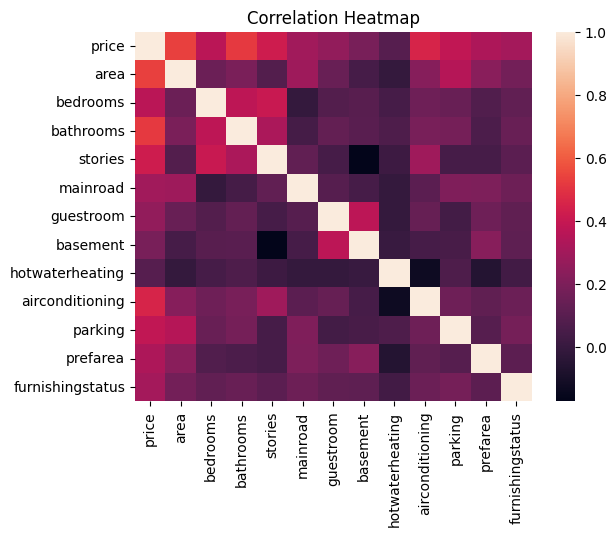

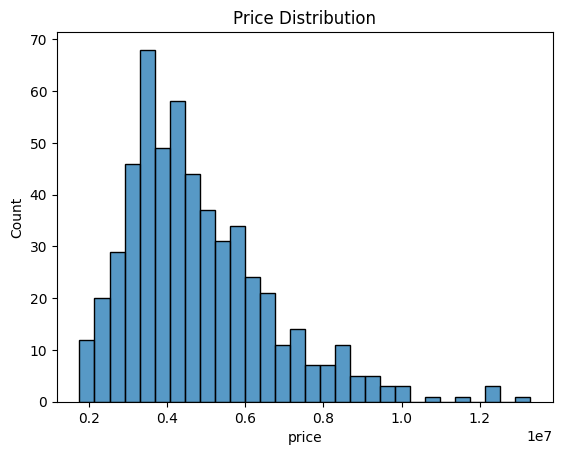

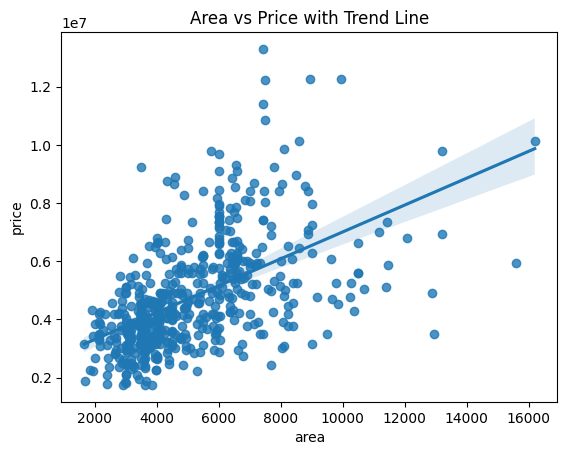

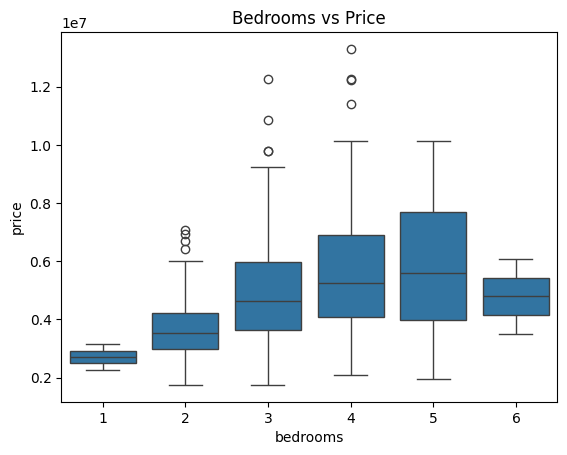

In [29]:
# 4. BASIC DATA ANALYSIS (EDA)
# ================================

# Summary statistics
print(df.describe())

# Correlation heatmap
plt.figure()
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Price distribution
plt.figure()
sns.histplot(df['price'], bins=30)
plt.title("Price Distribution")
plt.show()

# Area vs Price
# plt.figure()
# sns.scatterplot(x=df['area'], y=df['price'])
# plt.title("Area vs Price")
# plt.show()

# Area vs Price
plt.figure()
sns.regplot(x=df['area'], y=df['price'])
plt.title("Area vs Price with Trend Line")
plt.show()

# Bedrooms vs Price
plt.figure()
sns.boxplot(x=df['bedrooms'], y=df['price'])
plt.title("Bedrooms vs Price")
plt.show()

In [30]:
# 5. FEATURE & TARGET SEPARATION
X = df.drop('price', axis=1)   # Features
y = df['price']                # Target

In [31]:
# 6. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# 7. MODEL 1: LINEAR REGRESSION

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression R2: 0.6494754192267803
Linear Regression RMSE: 1331071.4167895108


In [33]:
# 8. MODEL 2: DECISION TREE

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Decision Tree R2: 0.4443624157070456
Decision Tree RMSE: 1675860.734466431


In [34]:
# 9. MODEL 3: RANDOM FOREST

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R2: 0.612840442148196
Random Forest RMSE: 1398901.4195830664


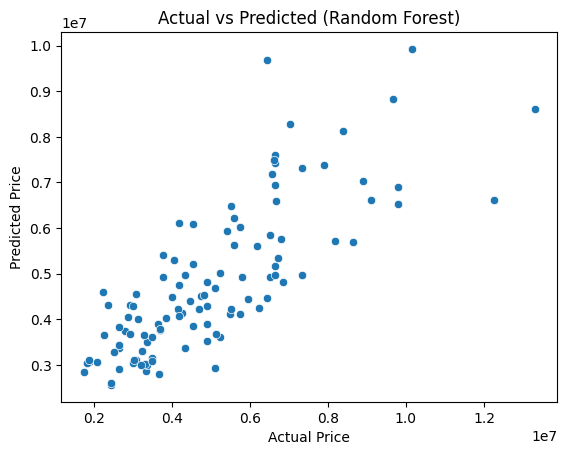

In [35]:
# Actual vs Predicted (Random Forest)
plt.figure()
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [36]:
# 10. MODEL 4: GRADIENT BOOSTING

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting R2:", r2_score(y_test, y_pred_gb))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

Gradient Boosting R2: 0.6647319259695589
Gradient Boosting RMSE: 1301781.8678828645


In [37]:
# 11. MODEL COMPARISON

models = ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]

r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_gb)
]

rmse_scores = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_dt)),
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    np.sqrt(mean_squared_error(y_test, y_pred_gb))
]

comparison = pd.DataFrame({
    "Model": models,
    "R2 Score": r2_scores,
    "RMSE": rmse_scores
})

print("\nModel Comparison:")
print(comparison)


Model Comparison:
               Model  R2 Score          RMSE
0  Linear Regression  0.649475  1.331071e+06
1      Decision Tree  0.444362  1.675861e+06
2      Random Forest  0.612840  1.398901e+06
3  Gradient Boosting  0.664732  1.301782e+06


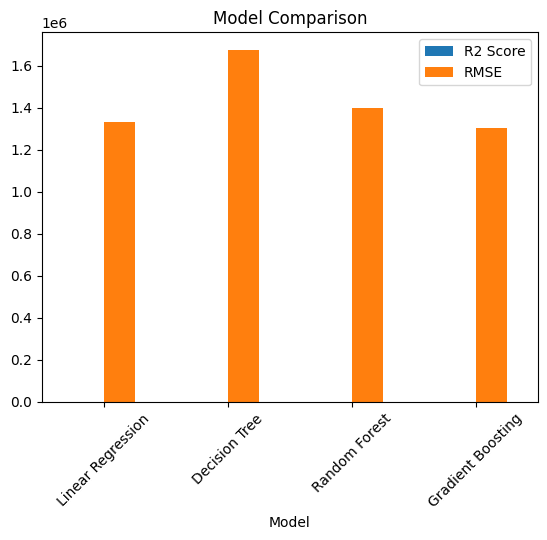

In [38]:
# Model Comparison Bar Chart
comparison.set_index("Model")[["R2 Score", "RMSE"]].plot(kind='bar')
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

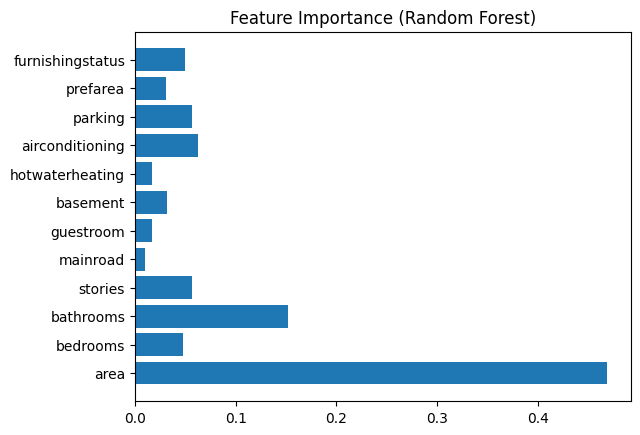

In [39]:
# 12. FEATURE IMPORTANCE (Random Forest)

importance = rf.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importance)
plt.title("Feature Importance (Random Forest)")
plt.show()

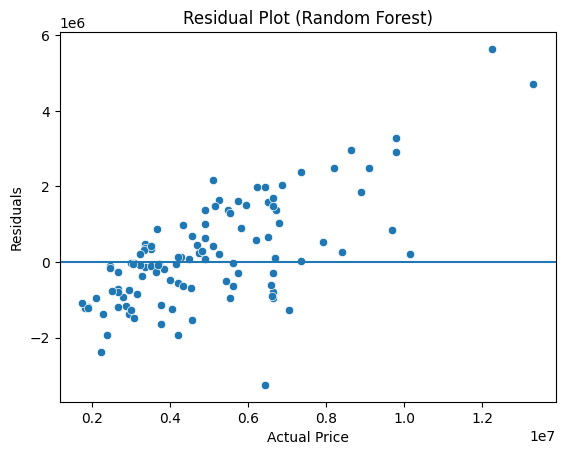

In [40]:
# 13. RESIDUAL PLOT (MODEL CHECK)
# ================================
plt.figure()
sns.scatterplot(x=y_test, y=y_test - y_pred_rf)
plt.axhline(0)
plt.title("Residual Plot (Random Forest)")
plt.xlabel("Actual Price")
plt.ylabel("Residuals")
plt.show()